# Random Forest Project
Predicting whether LendingClub borrowers paid back their loans in full (2007–2010).

## 1. Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

## 2. Get the Data

In [ ]:
loans = pd.read_csv('loan_data.csv')
loans.info()

<class 'pandas.DataFrame'>
RangeIndex: 9578 entries, 0 to 9577
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   credit.policy      9578 non-null   int64  
 1   purpose            9578 non-null   object 
 2   int.rate           9578 non-null   float64
 3   installment        9578 non-null   float64
 4   log.annual.inc     9578 non-null   float64
 5   dti                9578 non-null   float64
 6   fico               9578 non-null   int64  
 7   days.with.cr.line  9578 non-null   float64
 8   revol.bal          9578 non-null   int64  
 9   revol.util         9578 non-null   float64
10   inq.last.6mths     9578 non-null   int64  
11   delinq.2yrs        9578 non-null   int64  
12   pub.rec            9578 non-null   int64  
13   not.fully.paid     9578 non-null   int64  
dtypes: float64(6), int64(7), object(1)
memory usage: 1.0 MB


In [ ]:
loans.head()

   credit.policy             purpose  int.rate  ...  pub.rec  not.fully.paid
0              1  debt_consolidation    0.1189  ...        0               0
...


In [ ]:
loans.describe()

## 3. Exploratory Data Analysis

### FICO Distribution by Credit Policy

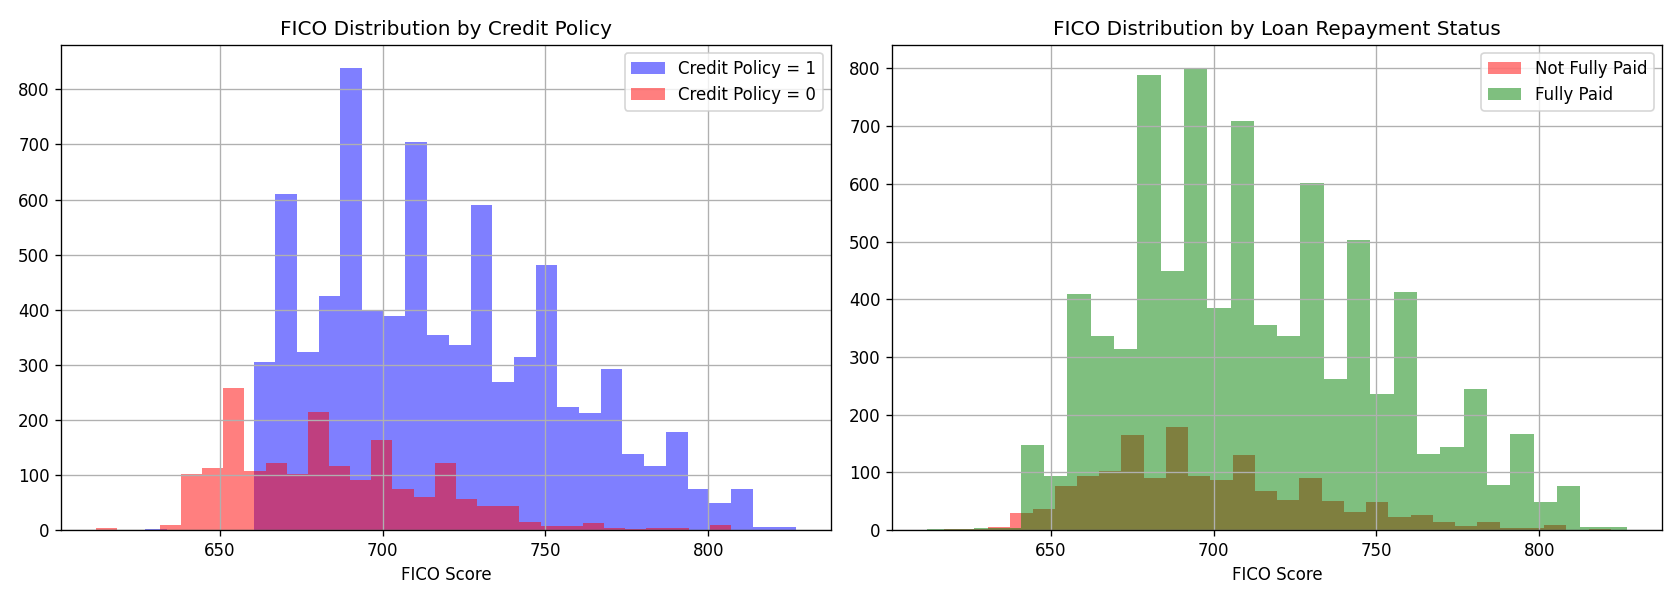

In [ ]:
loans[loans['credit.policy']==1]['fico'].hist(bins=30, color='blue', alpha=0.5, label='Credit Policy = 1')
loans[loans['credit.policy']==0]['fico'].hist(bins=30, color='red',  alpha=0.5, label='Credit Policy = 0')
plt.xlabel('FICO Score')
plt.title('FICO Distribution by Credit Policy')
plt.legend()
plt.show()

### FICO Distribution by Loan Repayment Status

In [ ]:
loans[loans['not.fully.paid']==1]['fico'].hist(bins=30, color='red',   alpha=0.5, label='Not Fully Paid')
loans[loans['not.fully.paid']==0]['fico'].hist(bins=30, color='green', alpha=0.5, label='Fully Paid')
plt.xlabel('FICO Score')
plt.title('FICO Distribution by Repayment Status')
plt.legend()
plt.show()

### Loan Count by Purpose

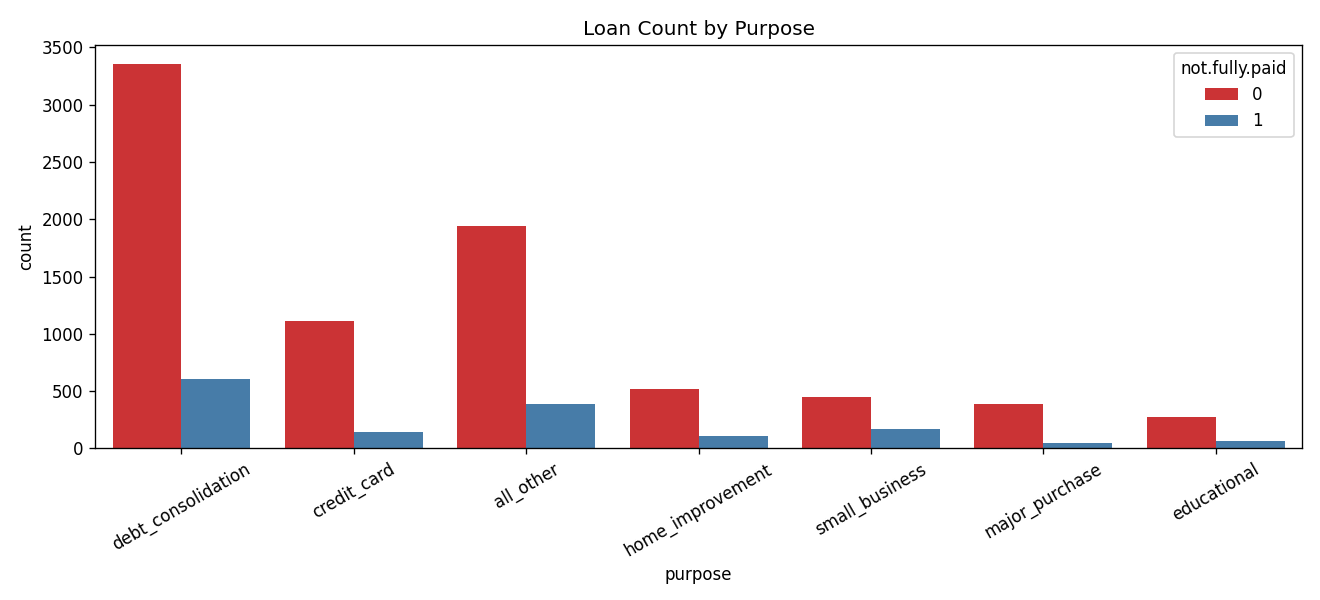

In [ ]:
plt.figure(figsize=(11,5))
sns.countplot(x='purpose', hue='not.fully.paid', data=loans, palette='Set1')
plt.xticks(rotation=30)
plt.title('Loan Count by Purpose')
plt.tight_layout()
plt.show()

### FICO Score vs Interest Rate (Jointplot)

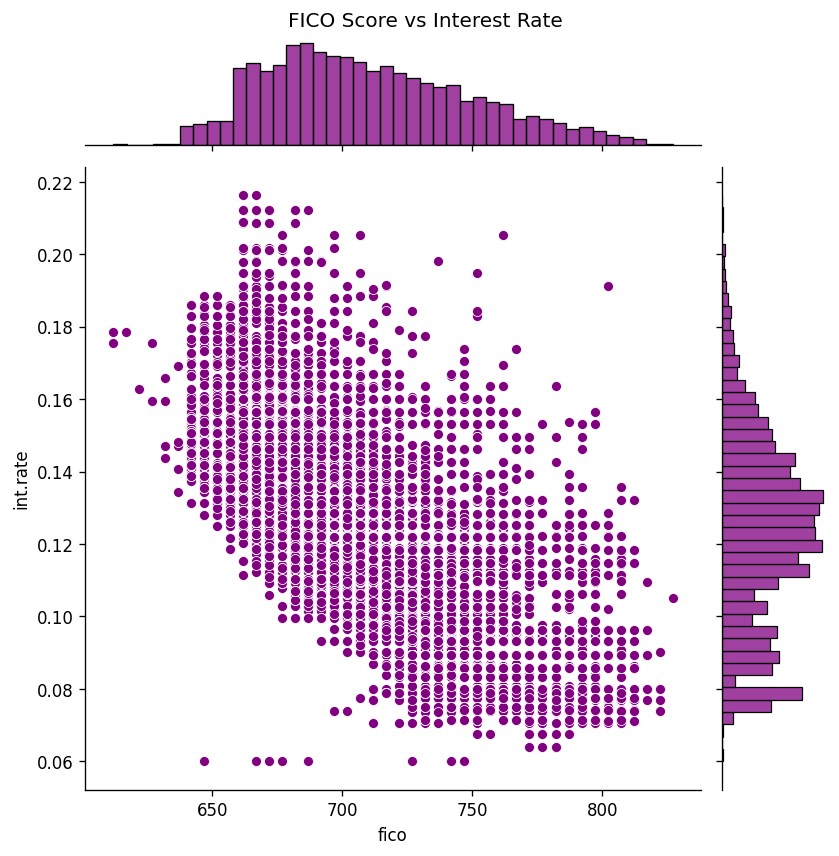

In [ ]:
sns.jointplot(x='fico', y='int.rate', data=loans, color='purple')
plt.show()

### lmplot: FICO vs Interest Rate split by credit.policy and not.fully.paid

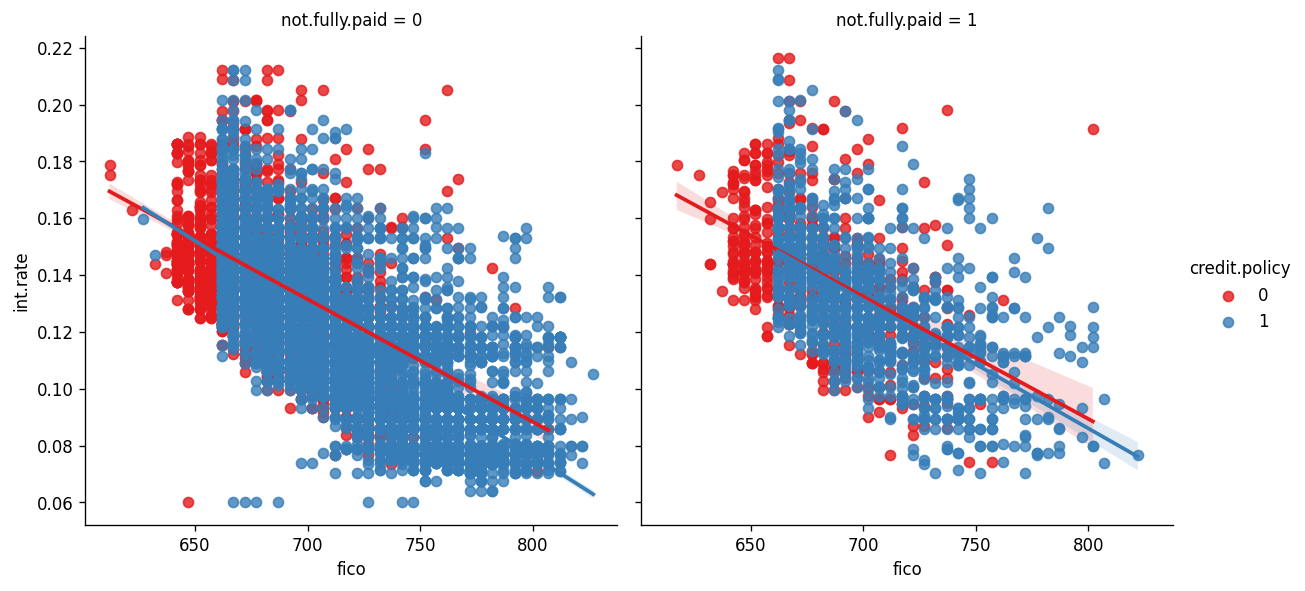

In [ ]:
sns.lmplot(x='fico', y='int.rate', data=loans,
           hue='credit.policy', col='not.fully.paid', palette='Set1')
plt.show()

## 4. Setting up the Data
The `purpose` column is categorical — we convert it to dummy variables.

In [ ]:
cat_feats = ['purpose']
final_data = pd.get_dummies(loans, columns=cat_feats, drop_first=True)
final_data.info()

## 5. Train / Test Split

In [ ]:
from sklearn.model_selection import train_test_split

X = final_data.drop('not.fully.paid', axis=1)
y = final_data['not.fully.paid']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=101
)
print('Train size:', X_train.shape)
print('Test size: ', X_test.shape)

Train size: (6704, 19)
Test size:  (2874, 19)


## 6. Decision Tree Model

In [ ]:
from sklearn.tree import DecisionTreeClassifier

dtree = DecisionTreeClassifier()
dtree.fit(X_train, y_train)

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

dt_preds = dtree.predict(X_test)

print('Classification Report:')
print(classification_report(y_test, dt_preds))
print('Confusion Matrix:')
print(confusion_matrix(y_test, dt_preds))

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.82      0.84      2431
           1       0.19      0.23      0.21       443

    accuracy                           0.73      2874
   macro avg       0.52      0.53      0.52      2874
weighted avg       0.75      0.73      0.74      2874

Confusion Matrix:
[[2001  430]
 [ 340  103]]


## 7. Random Forest Model

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rfc = RandomForestClassifier(n_estimators=200, random_state=101)
rfc.fit(X_train, y_train)

In [ ]:
rfc_preds = rfc.predict(X_test)

print('Classification Report:')
print(classification_report(y_test, rfc_preds))
print('Confusion Matrix:')
print(confusion_matrix(y_test, rfc_preds))

Classification Report:
              precision    recall  f1-score   support

           0       0.85      1.00      0.92      2431
           1       0.45      0.02      0.04       443

    accuracy                           0.85      2874
   macro avg       0.65      0.51      0.48      2874
weighted avg       0.79      0.85      0.78      2874

Confusion Matrix:
[[2419   12]
 [ 433   10]]


## 8. Conclusion

**Model Accuracy**:

Decision Tree: ~73%

Random Forest: ~85%


**Notes**: 

Decision Tree: Catches more defaulters (recall=0.23) but many false positives

Random Forest:  Higher overall accuracy, but almost ignores class 1 (recall≈0.02)

**Which performed better?**  
It depends on what we care about:

- **Overall accuracy**: Random Forest wins (85% vs 73%).
- **Detecting defaulters (class 1)**: Decision Tree is actually more useful here, catching 23% of defaults vs only 2% by the Random Forest.

The Random Forest essentially predicts everyone pays back because the dataset is heavily imbalanced (~84% fully paid). This is a classic imbalanced-class problem — techniques like SMOTE, class weighting (`class_weight='balanced'`), or adjusting the decision threshold would help the Random Forest better detect actual defaults.

For a real lending investor, missing a defaulter is costly, so recall on class 1 matters more than raw accuracy.